In [6]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import anndata as ad
from collections import Counter
from scipy.sparse import csr_matrix
import gc
import os, sys
import glob
gc.enable()

In [7]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=True, figsize=(5, 5))
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


=== TSP21 ===
T70
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
(6851, 2402)


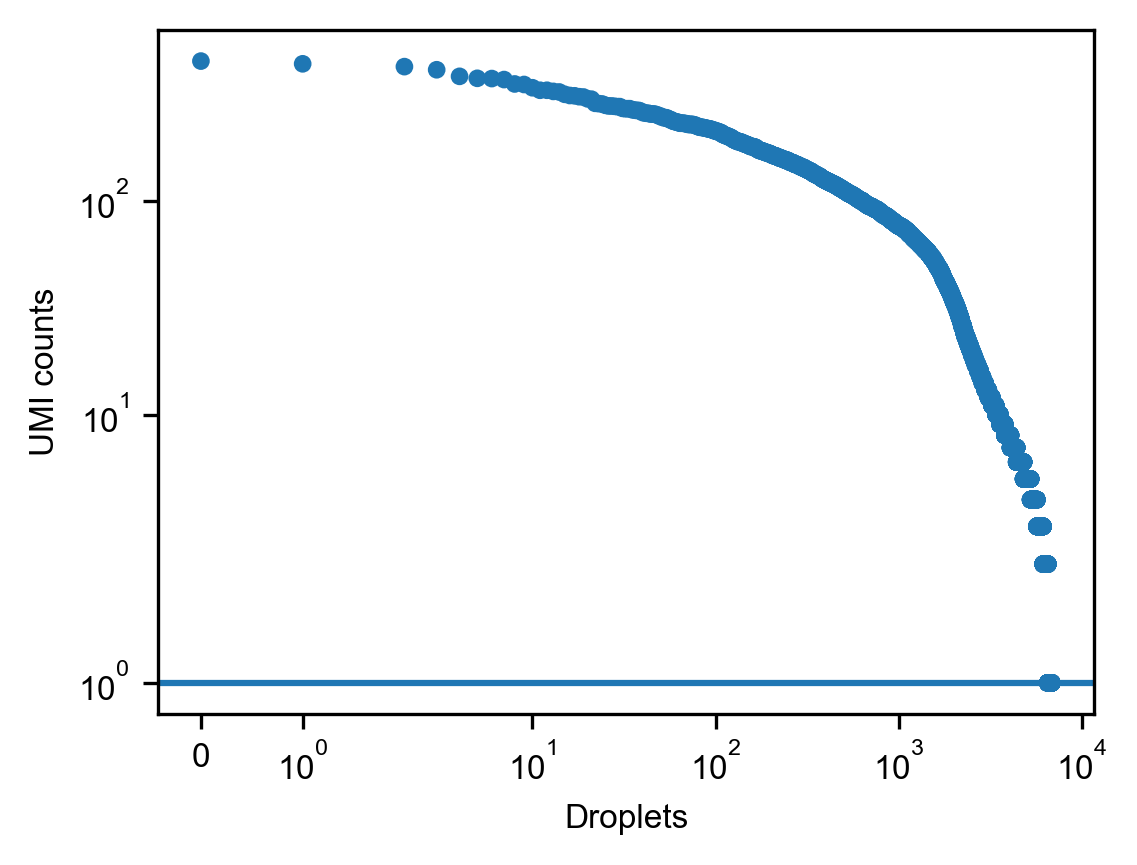

Pre-filtering:  (6851, 2402)
Post-filtering:  (6851, 2402)
  Saved TSP21: (6851, 2402) -> ./../pacbio_xgen/h5ads/TSP21_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad

=== TSP25 ===
T71
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
(9251, 3853)


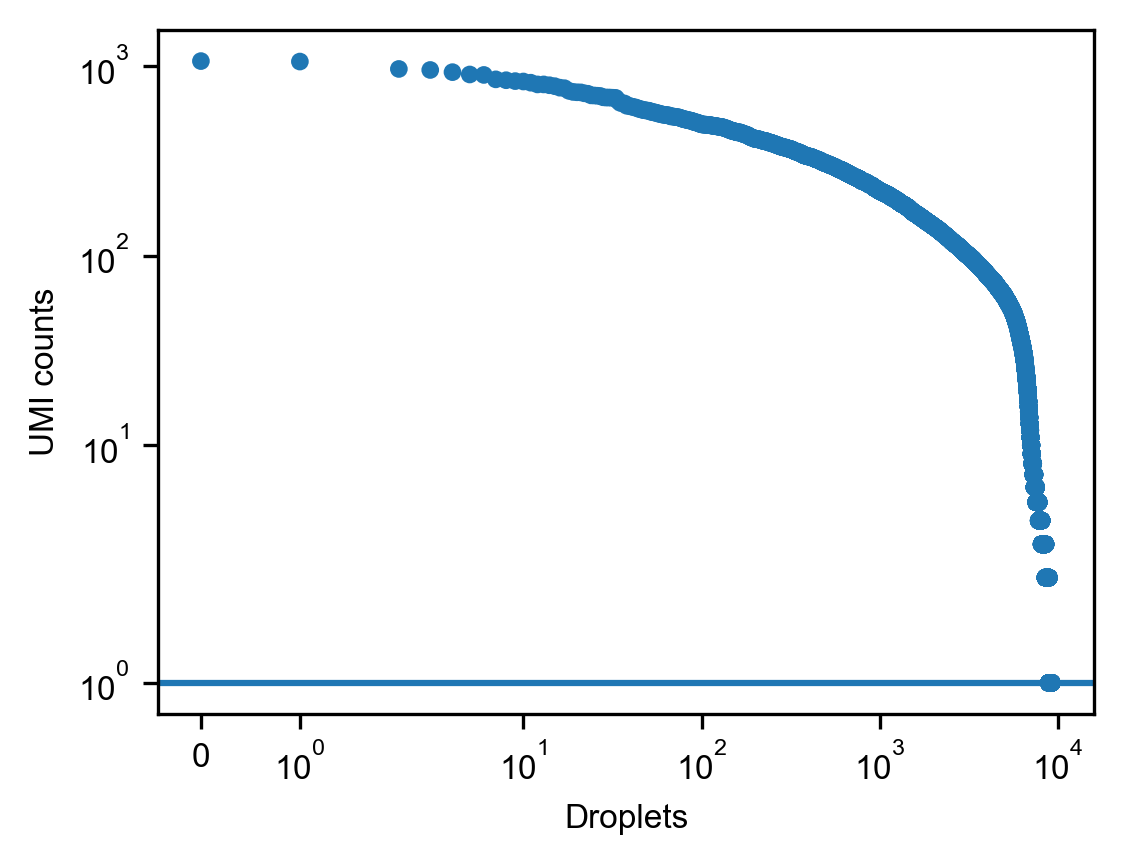

Pre-filtering:  (9251, 3853)
Post-filtering:  (9251, 3853)
  Saved TSP25: (9251, 3853) -> ./../pacbio_xgen/h5ads/TSP25_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad

=== TSP27 ===
T72
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
(11081, 4314)


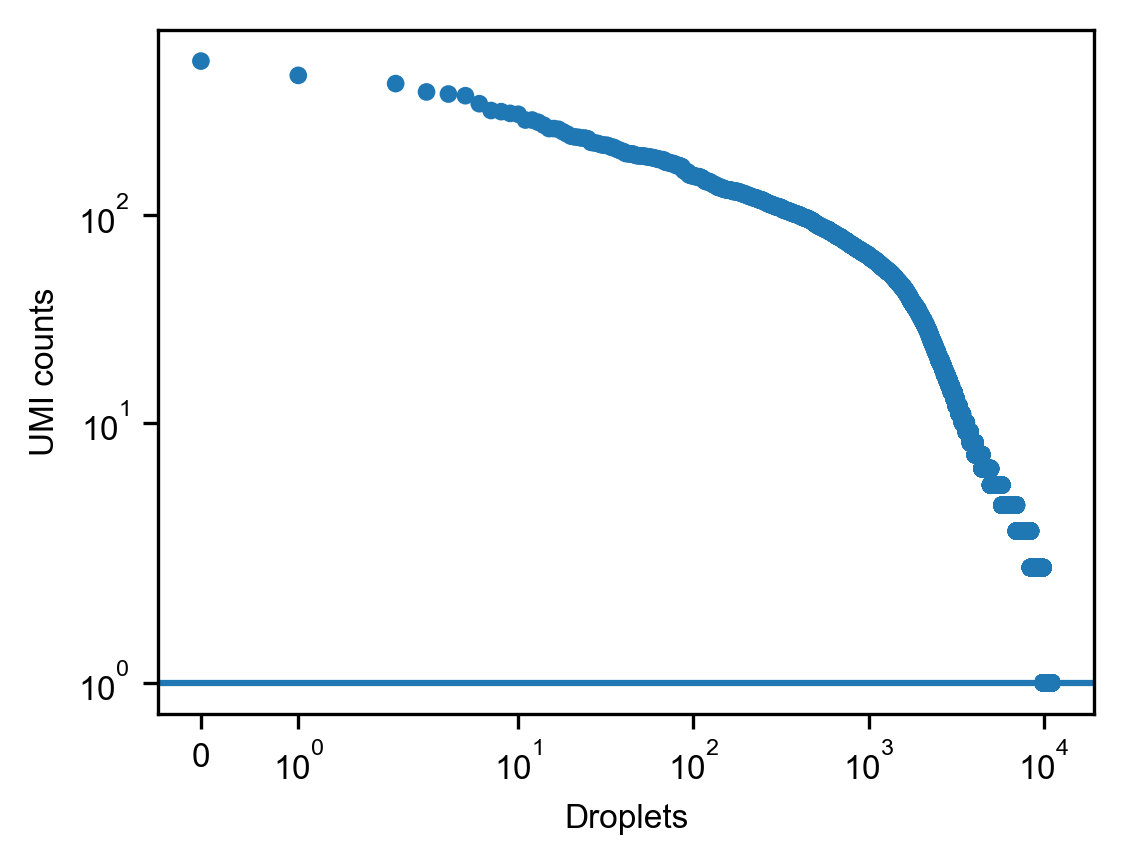

Pre-filtering:  (11081, 4314)
Post-filtering:  (11081, 4314)
  Saved TSP27: (11081, 4314) -> ./../pacbio_xgen/h5ads/TSP27_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad

=== TSP33 ===
T73
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
(5019, 2124)


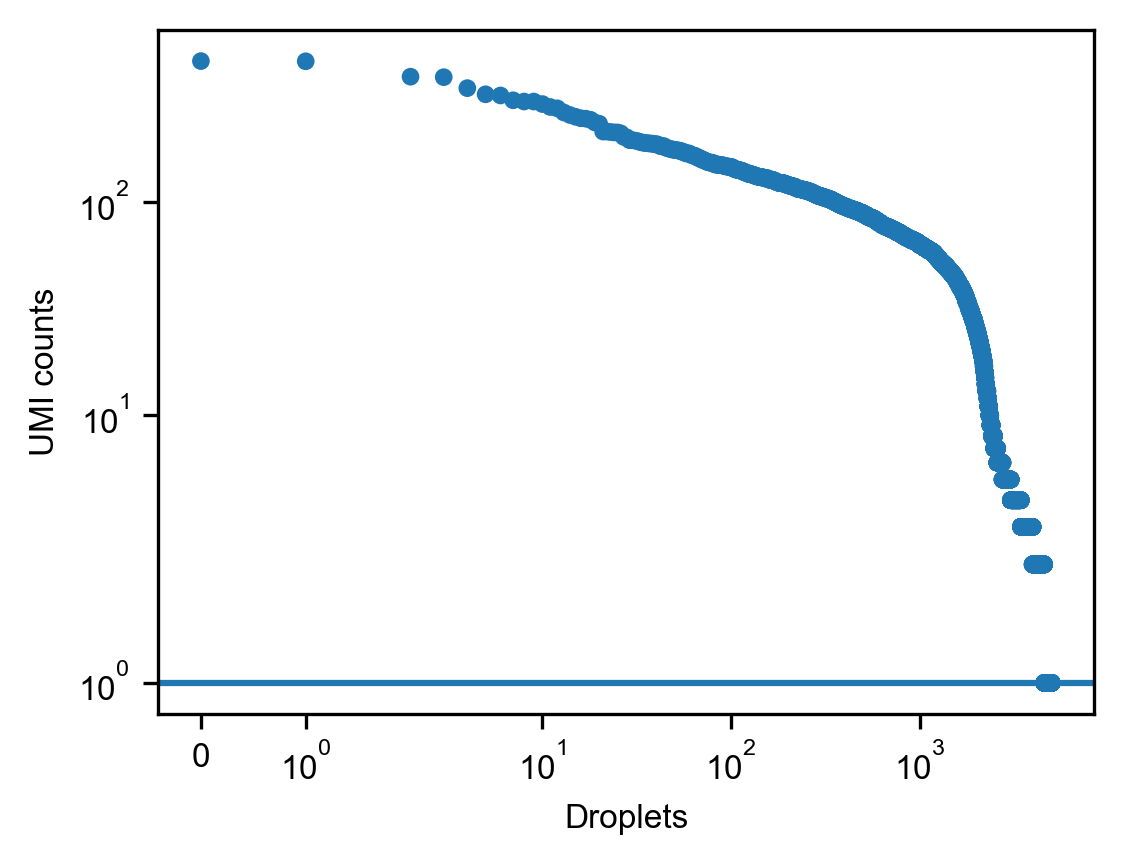

Pre-filtering:  (5019, 2124)
Post-filtering:  (5019, 2124)
  Saved TSP33: (5019, 2124) -> ./../pacbio_xgen/h5ads/TSP33_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad

=== TSP33.1 ===
X33
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
(68853, 20701)


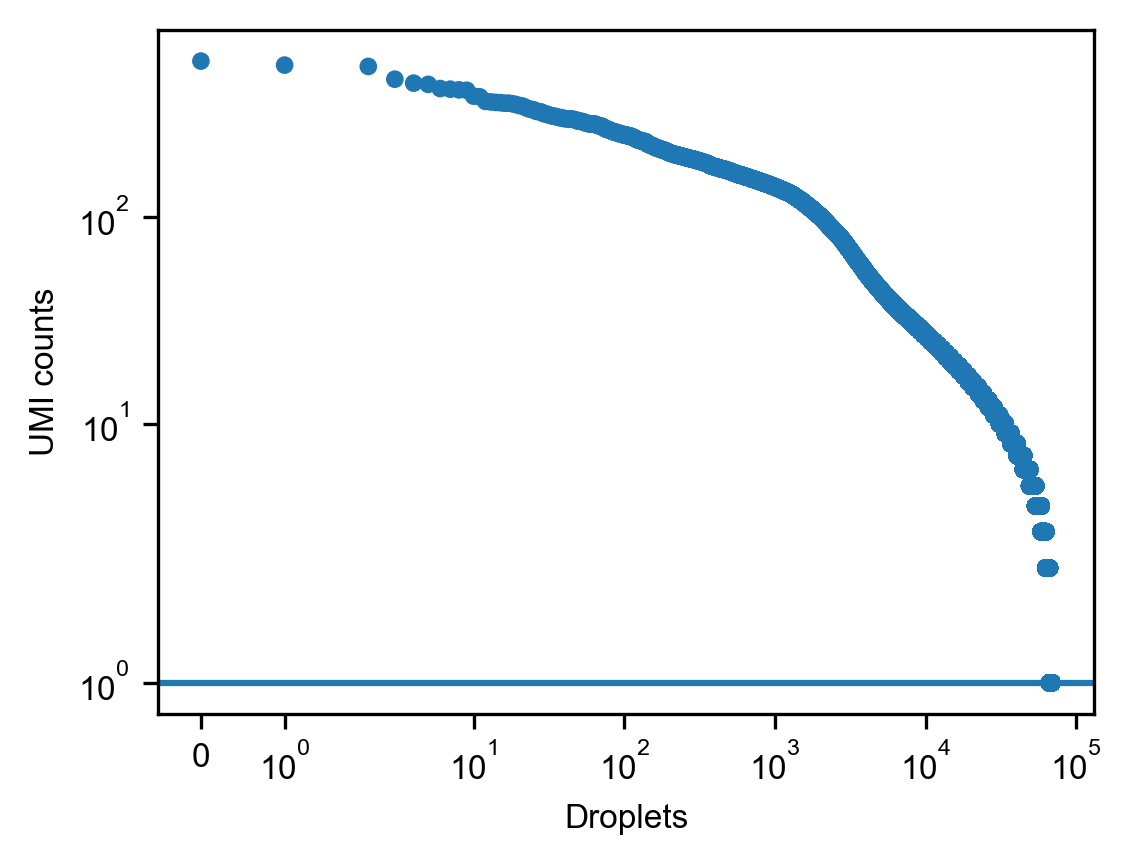

Pre-filtering:  (68853, 20701)
Post-filtering:  (68853, 20701)
  Saved TSP33.1: (68853, 20701) -> ./../pacbio_xgen/h5ads/TSP33.1_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad


In [8]:
BASEDIR = "./../pacbio_xgen/pigeon/"

sample_metadata = pd.read_csv("./../csvs/xgen_metadata.csv")
donors = sorted(sample_metadata["donor"].dropna().unique())
donors = [d for d in donors if d != "TSP31"]  # exclude donor TSP31

os.makedirs("./../pacbio/h5ads", exist_ok=True)

for donor in donors:
    print(f"\n=== {donor} ===")
    donor_tubes = sorted(
        sample_metadata.loc[sample_metadata["donor"] == donor, "tube_id"].dropna().unique()
    )
    adata_dict = dict()
    for tissue in donor_tubes:
        seurat_dir = f"{BASEDIR}/seurat_pbids/{tissue}/genes_seurat/"
        if not os.path.isdir(seurat_dir):
            print(f"Skipping {tissue}: {seurat_dir} not found")
            continue
        print(tissue)
        adata = sc.read_10x_mtx(seurat_dir)
        adata.var["gene_id"] = adata.var["gene_ids"].str.split(":").str[0]
        adata.var["gene_name"] = adata.var["gene_ids"].str.split(":").str[1]
        adata.var_names = adata.var.gene_name
        adata.var_names_make_unique()

        # Cap percent_top to number of features (tissues like T4 can have < 500)
        n_vars = adata.n_vars
        percent_top = [n for n in [50, 100, 200, 500] if n <= n_vars]
        sc.pp.calculate_qc_metrics(adata, percent_top=percent_top, inplace=True, log1p=True)
        print(adata.shape)
        data = adata.obs[["total_counts"]].sort_values(by="total_counts", ascending=False)
        data["cell_number"] = [i for i in range(data.shape[0])]
        sc.settings.set_figure_params(dpi=150, dpi_save=300, fontsize=8, frameon=True, figsize=(3, 3), transparent=False, format="pdf")
        fig, ax = plt.subplots(figsize=(4.0, 3.0))
        plt.rc('font', size=6)
        ax.set_axisbelow(True)
        plt.grid(False)
        plt.xlabel("Droplets")
        plt.ylabel("UMI counts")
        sns.scatterplot(data=data, x="cell_number", y="total_counts", linewidth=0, size=1.0, rasterized=True, legend=None, ax=ax)
        plt.xscale('symlog')
        plt.yscale('symlog')
        plt.axhline(1)
        plt.show()
        adata.obs["tube_id"] = tissue
        print("Pre-filtering: ", adata.shape)
        sc.pp.filter_cells(adata, min_counts=1)
        print("Post-filtering: ", adata.shape)
        adata_dict[tissue] = adata

    if not adata_dict:
        print(f"  No tissues found for {donor}, skipping write")
        continue

    # Gene names are shared across tissues — no prefix needed
    all_var = pd.concat([a.var for a in adata_dict.values()], join="outer")
    all_var_dedup = all_var[~all_var.index.duplicated()]

    adata = ad.concat(adatas=adata_dict.values(), join="outer", keys=adata_dict.keys(), index_unique="_")
    adata.var = all_var_dedup.loc[adata.var_names]
    adata.var.index = adata.var.index.values
    adata.obs = adata.obs.join(sample_metadata.set_index("tube_id"), on="tube_id")

    # Fill NaN in string/object columns so h5ad can write them
    for col in adata.var.columns:
        if adata.var[col].dtype == object:
            adata.var[col] = adata.var[col].fillna("")

    out_path = f"./../pacbio_xgen/h5ads/{donor}_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad"
    adata.write_h5ad(out_path)
    print(f"  Saved {donor}: {adata.shape} -> {out_path}")

    del adata_dict, adata, all_var, all_var_dedup
    gc.collect()

In [9]:
# Spot-check one per-donor h5ad; run 00c_merge_per_donor_h5ads.ipynb to build the all-samples object.
adata1 = sc.read_h5ad("./../pacbio_xgen/h5ads/TSP25_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad")
adata1

AnnData object with n_obs × n_vars = 9251 × 3853
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id'
    var: 'gene_ids', 'gene_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [5]:
# Spot-check one per-donor h5ad; run 00c_merge_per_donor_h5ads.ipynb to build the all-samples object.
adata1 = sc.read_h5ad("./../pacbio_xgen/h5ads/TSP33_pacbio_xgen_raw_counts_genes_bc_anndata_mincounts500.h5ad")
adata1

AnnData object with n_obs × n_vars = 5019 × 2124
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id'
    var: 'gene_ids', 'gene_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'